# 🌤️ End-to-End Machine Learning Pipeline: Predicting Rain in Australia

## 📌 Project Overview & Workflow
This notebook presents a complete, end-to-end Machine Learning pipeline designed to predict whether it will rain tomorrow (`RainTomorrow`) based on historical meteorological data. 

To ensure high model accuracy, academic rigor, and professional presentation, the project follows a structured workflow:

1. **Data Preprocessing & Cleaning**: Handling missing values, dropping `RISK_MM` to prevent data leakage, and encoding binary variables.
2. **Exploratory Data Analysis (EDA)**: Visualizing feature distributions, class imbalances, and correlations.
3. **Feature Engineering & Scaling**: Normalizing numerical features using `StandardScaler`.
4. **Model Training & Comparison**: Evaluating Logistic Regression, KNN, SVM, and Random Forest.
5. **Conclusion & Evaluation Metrics**: Comparing models using Accuracy, Precision, Recall, and F1-Score.




### ---------------------------------------------


1. Importing Libraries & Loading Dataset

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv("weatherAUS.csv")

In [7]:
df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RISK_MM,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,0.0,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,0.0,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,0.0,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,1.0,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,0.2,No


In [8]:
df.tail()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RISK_MM,RainTomorrow
142188,2017-06-20,Uluru,3.5,21.8,0.0,NaN,NaN,E,31.0,ESE,...,27.0,1024.7,1021.2,NaN,NaN,9.4,20.9,No,0.0,No
142189,2017-06-21,Uluru,2.8,23.4,0.0,NaN,NaN,E,31.0,SE,...,24.0,1024.6,1020.3,NaN,NaN,10.1,22.4,No,0.0,No
142190,2017-06-22,Uluru,3.6,25.3,0.0,NaN,NaN,NNW,22.0,SE,...,21.0,1023.5,1019.1,NaN,NaN,10.9,24.5,No,0.0,No
142191,2017-06-23,Uluru,5.4,26.9,0.0,NaN,NaN,N,37.0,SE,...,24.0,1021.0,1016.8,NaN,NaN,12.5,26.1,No,0.0,No
142192,2017-06-24,Uluru,7.8,27.0,0.0,NaN,NaN,SE,28.0,SSE,...,24.0,1019.4,1016.5,3.0,2.0,15.1,26.0,No,0.0,No


2. Initial Data Inspection & Understanding

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 142193 entries, 0 to 142192
Data columns (total 24 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           142193 non-null  str    
 1   Location       142193 non-null  str    
 2   MinTemp        141556 non-null  float64
 3   MaxTemp        141871 non-null  float64
 4   Rainfall       140787 non-null  float64
 5   Evaporation    81350 non-null   float64
 6   Sunshine       74377 non-null   float64
 7   WindGustDir    132863 non-null  str    
 8   WindGustSpeed  132923 non-null  float64
 9   WindDir9am     132180 non-null  str    
 10  WindDir3pm     138415 non-null  str    
 11  WindSpeed9am   140845 non-null  float64
 12  WindSpeed3pm   139563 non-null  float64
 13  Humidity9am    140419 non-null  float64
 14  Humidity3pm    138583 non-null  float64
 15  Pressure9am    128179 non-null  float64
 16  Pressure3pm    128212 non-null  float64
 17  Cloud9am       88536 non-null   float64


In [10]:
df.describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RISK_MM
count,141556.000000,141871.000000,140787.000000,81350.000000,74377.000000,132923.000000,140845.000000,139563.000000,140419.000000,138583.000000,128179.000000,128212.000000,88536.000000,85099.000000,141289.000000,139467.000000,142193.000000
mean,12.186400,23.226784,2.349974,5.469824,7.624853,39.984292,14.001988,18.637576,68.843810,51.482606,1017.653758,1015.258204,4.437189,4.503167,16.987509,21.687235,2.360682
std,6.403283,7.117618,8.465173,4.188537,3.781525,13.588801,8.893337,8.803345,19.051293,20.797772,7.105476,7.036677,2.887016,2.720633,6.492838,6.937594,8.477969
min,-8.500000,-4.800000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.500000,977.100000,0.000000,0.000000,-7.200000,-5.400000,0.000000
25%,7.600000,17.900000,0.000000,2.600000,4.900000,31.000000,7.000000,13.000000,57.000000,37.000000,1012.900000,1010.400000,1.000000,2.000000,12.300000,16.600000,0.000000
50%,12.000000,22.600000,0.000000,4.800000,8.500000,39.000000,13.000000,19.000000,70.000000,52.000000,1017.600000,1015.200000,5.000000,5.000000,16.700000,21.100000,0.000000
75%,16.800000,28.200000,0.800000,7.400000,10.600000,48.000000,19.000000,24.000000,83.000000,66.000000,1022.400000,1020.000000,7.000000,7.000000,21.600000,26.400000,0.800000
max,33.900000,48.100000,371.000000,145.000000,14.500000,135.000000,130.000000,87.000000,100.000000,100.000000,1041.000000,1039.600000,9.000000,9.000000,40.200000,46.700000,371.000000


In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
print(df.shape)

(142193, 24)


In [13]:
df.columns

Index(['Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation',
       'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm',
       'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
       'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am',
       'Temp3pm', 'RainToday', 'RISK_MM', 'RainTomorrow'],
      dtype='str')

3. Data Cleaning & Preprocessing

In [45]:
numeric_cols = df.select_dtypes(include='number').columns
categorical_cols = df.select_dtypes(include=['object', 'str']).columns

print("Numerical Columns:")
print(list(numeric_cols))

print("\nCategorical Columns:")
print(list(categorical_cols))

Numerical Columns:
['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm', 'RainTomorrow', 'Year', 'Month', 'Day']

Categorical Columns:
['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday']


In [15]:
df.isnull().sum()

Date                 0
Location             0
MinTemp            637
MaxTemp            322
Rainfall          1406
Evaporation      60843
Sunshine         67816
WindGustDir       9330
WindGustSpeed     9270
WindDir9am       10013
WindDir3pm        3778
WindSpeed9am      1348
WindSpeed3pm      2630
Humidity9am       1774
Humidity3pm       3610
Pressure9am      14014
Pressure3pm      13981
Cloud9am         53657
Cloud3pm         57094
Temp9am            904
Temp3pm           2726
RainToday         1406
RISK_MM              0
RainTomorrow         0
dtype: int64

In [16]:
numeric_col = [
    "MinTemp",
    "MaxTemp",
    "Rainfall",
    "Evaporation",
    "Sunshine",
    "WindGustSpeed",
    "WindSpeed9am",
    "WindSpeed3pm",
    "Humidity9am",
    "Humidity3pm",
    "Pressure9am",
    "Pressure3pm",
    "Cloud9am",
    "Cloud3pm",
    "Temp9am",
    "Temp3pm"
]
for col in numeric_col:
    median = df.groupby("Location")[col].transform("median")
    df[col] = df[col].fillna(median)
    df[col] = df[col].fillna(df[col].median())


In [17]:
categorical_col = [
    "WindGustDir",
    "WindDir9am",
    "WindDir3pm",
    "RainToday"
]

for col in categorical_col:
    df[col] = df[col].fillna(df[col].mode()[0])

In [ ]:
df.drop(["RISK_MM"],axis=1,inplace=True)

In [18]:
numeric_cols = df.select_dtypes(include='number').columns

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]

    print(f"{col}: {len(outliers)} outliers")

MinTemp: 62 outliers
MaxTemp: 459 outliers
Rainfall: 28545 outliers
Evaporation: 15895 outliers
Sunshine: 27853 outliers
WindGustSpeed: 5386 outliers
WindSpeed9am: 1739 outliers
WindSpeed3pm: 2458 outliers
Humidity9am: 1419 outliers
Humidity3pm: 0 outliers
Pressure9am: 2708 outliers
Pressure3pm: 2305 outliers
Cloud9am: 0 outliers
Cloud3pm: 0 outliers
Temp9am: 292 outliers
Temp3pm: 779 outliers
RISK_MM: 25573 outliers


Outlier Handling: Outliers were identified using the IQR method. They were not removed because extreme weather measurements can represent real weather conditions and may contain useful information for predicting rainfall. Therefore, the identified outliers were retained.

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day


In [20]:
df.drop('Date', axis=1, inplace=True)

4. Exploratory Data Analysis - EDA

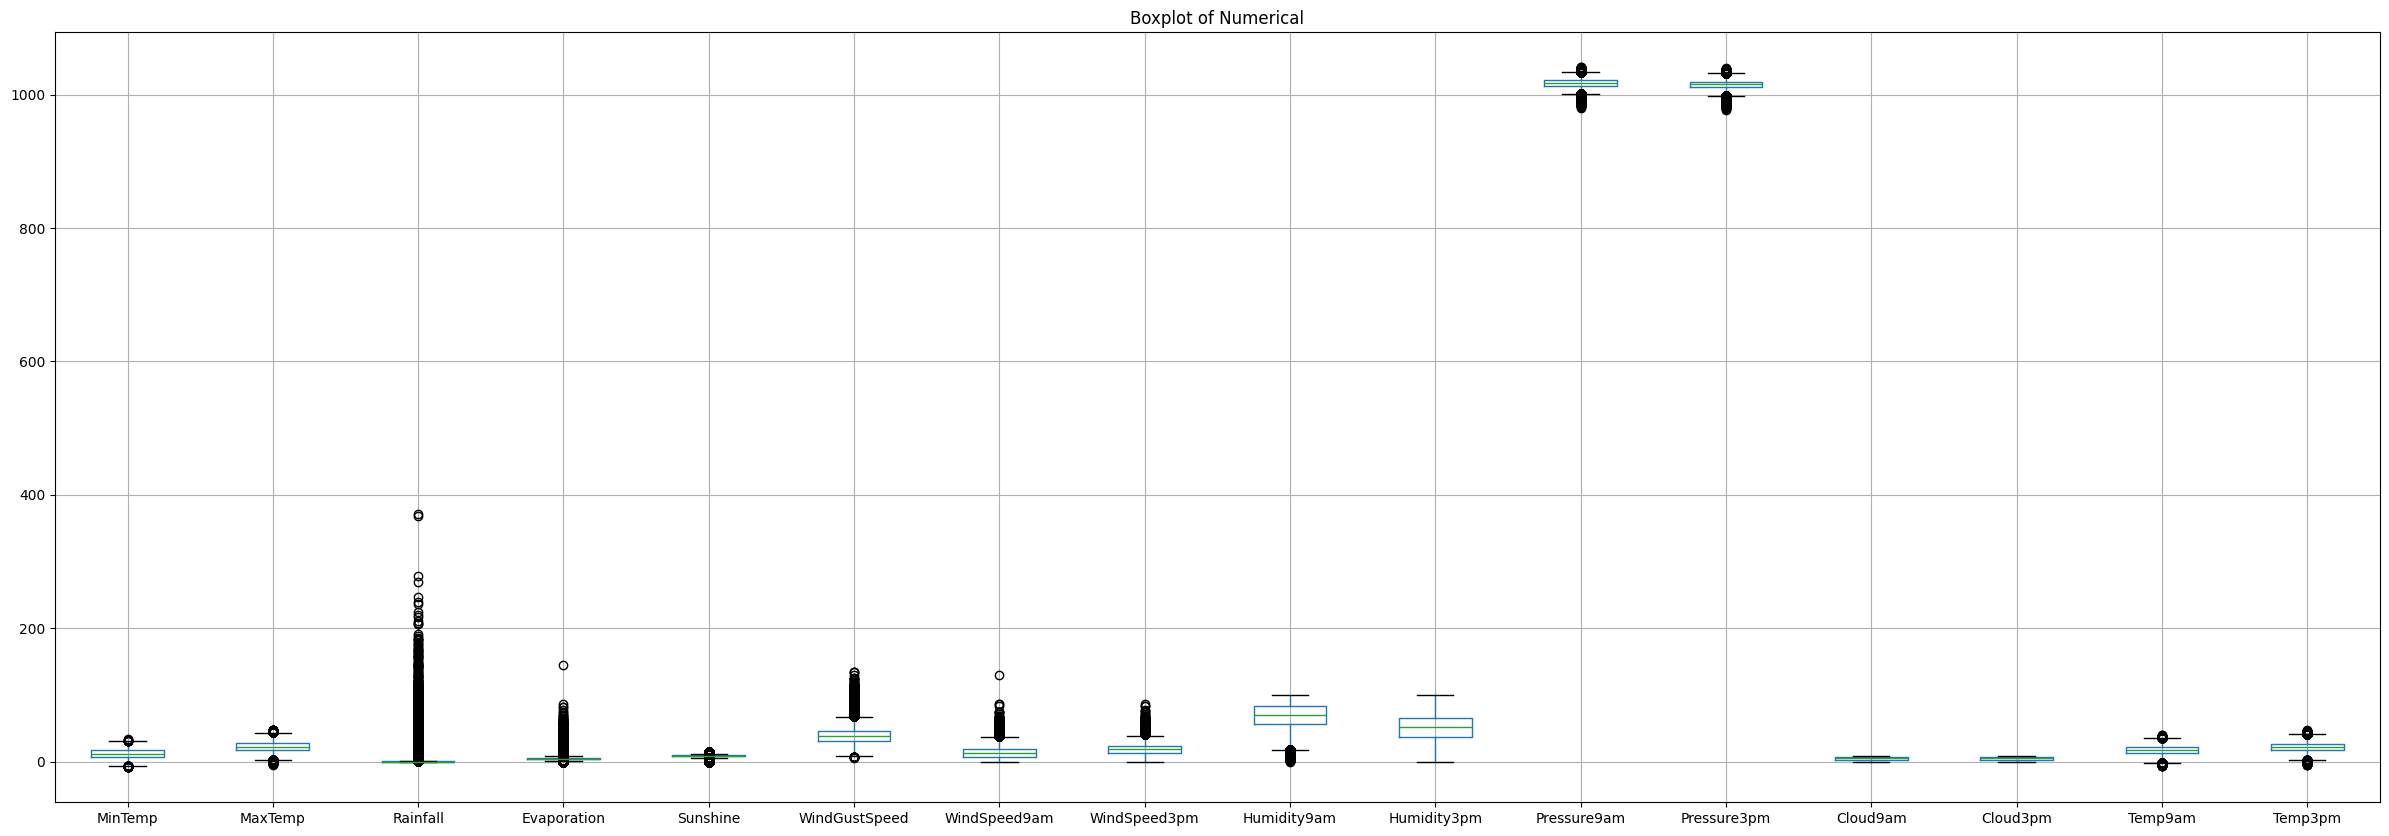

In [21]:
plt.figure(figsize=(30, 10))

df[numeric_col].boxplot()
plt.title('Boxplot of Numerical')
plt.show()

Why did you choose this visualization?

I chose the boxplot to identify the spread of numerical variables and detect potential outliers.

What does this graph help you understand?

It helps identify the median, variability, and unusual values in the numerical variables.

Insight:

Most variables have some outliers, especially variables related to rainfall and wind speed. These extreme values may represent real weather conditions, so they were retained.

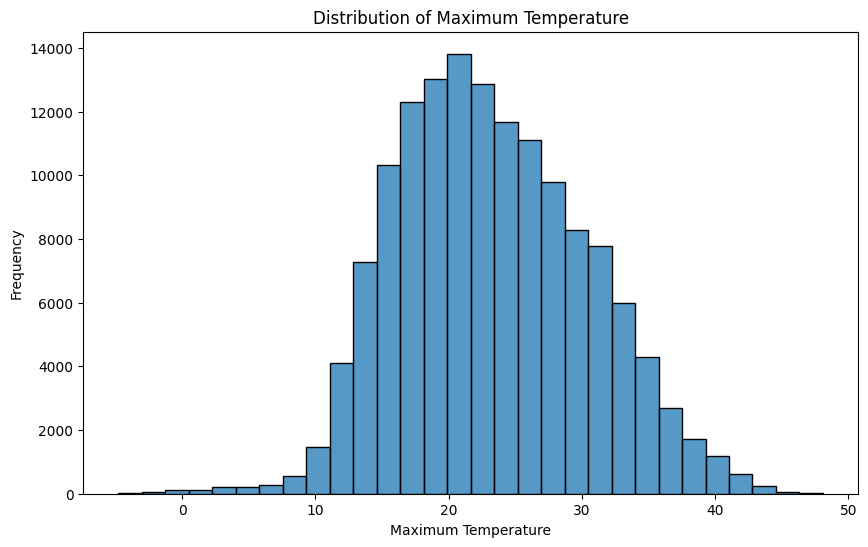

In [22]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x='MaxTemp',
    bins=30
)

plt.title('Distribution of Maximum Temperature')
plt.xlabel('Maximum Temperature')
plt.ylabel('Frequency')

plt.show()

Why did you choose this visualization?

I chose the histogram to understand the distribution of maximum temperature values.

What does this graph help you understand?

It shows the most common temperature range and how the values are distributed.

Insight:

Maximum temperature is mainly concentrated around the moderate temperature range, with fewer observations at very low or very high temperatures.

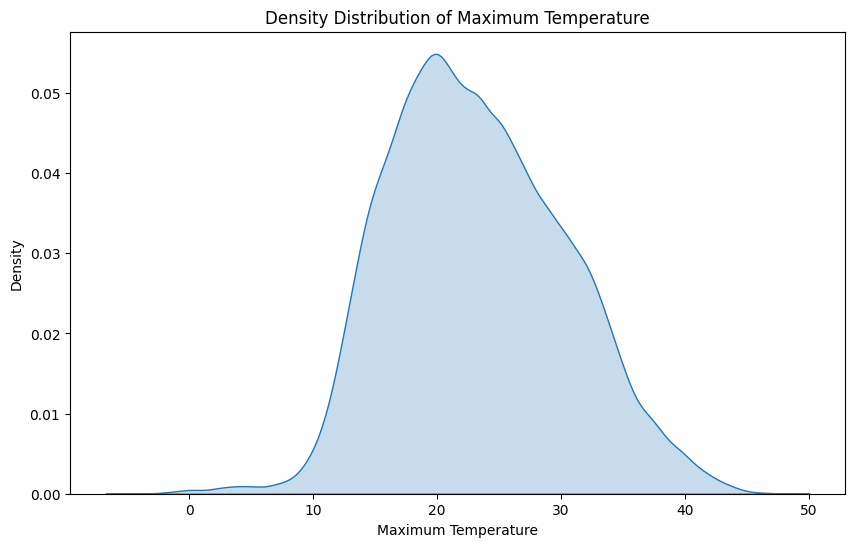

In [23]:
plt.figure(figsize=(10, 6))

sns.kdeplot(
    data=df,
    x='MaxTemp',
    fill=True
)

plt.title('Density Distribution of Maximum Temperature')
plt.xlabel('Maximum Temperature')
plt.ylabel('Density')

plt.show()

Why did you choose this visualization?

I chose the KDE plot to observe the shape of the maximum temperature distribution more clearly.

What does this graph help you understand?

It shows where maximum temperature values are most concentrated and whether the distribution is skewed.

Insight:

The distribution is concentrated around moderate temperatures and gradually decreases toward higher temperatures, showing fewer extreme values.

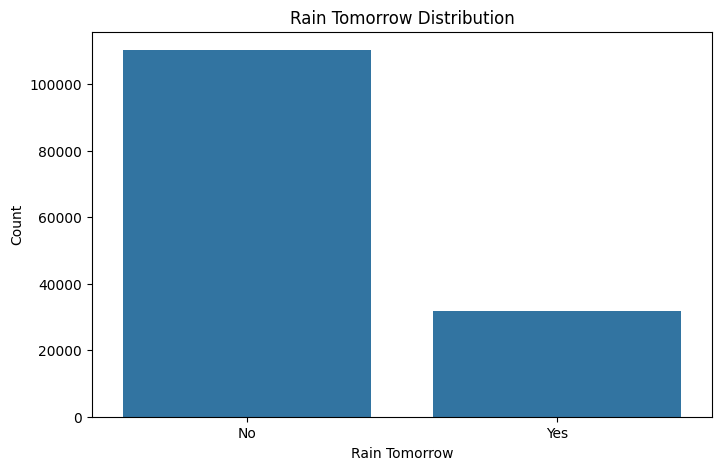

In [24]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='RainTomorrow'
)

plt.title('Rain Tomorrow Distribution')
plt.xlabel('Rain Tomorrow')
plt.ylabel('Count')

plt.show()

Why did you choose this visualization?

I chose the bar chart to compare the number of rainy and non-rainy days.

What does this graph help you understand?

It shows the class distribution of the target variable RainTomorrow.

Insight:

There are significantly more non-rainy days than rainy days. This indicates that the target variable is imbalanced.

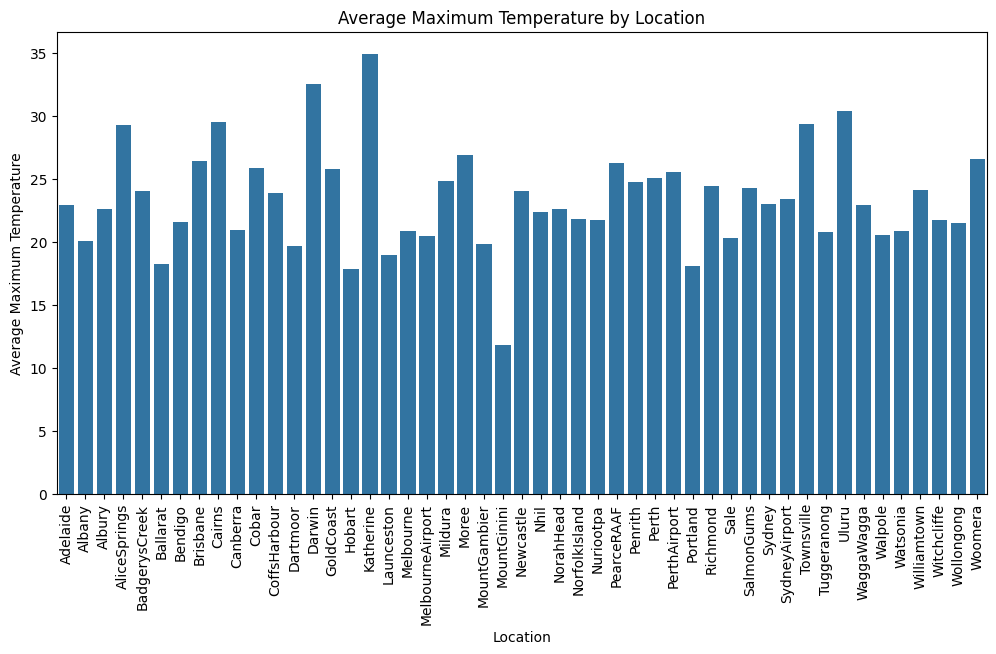

In [25]:
plt.figure(figsize=(12, 6))

avg_temp = df.groupby('Location')['MaxTemp'].mean()

sns.barplot(
    x=avg_temp.index,
    y=avg_temp.values
)

plt.title('Average Maximum Temperature by Location')
plt.xlabel('Location')
plt.ylabel('Average Maximum Temperature')

plt.xticks(rotation=90)

plt.show()

Why did you choose this visualization?

I chose the bar chart to compare the average maximum temperature across different locations.

What does this graph help you understand?

It shows how maximum temperature varies between different weather stations.

Insight:

The average maximum temperature differs between locations. Some locations have noticeably higher temperatures, while others have lower average temperatures.

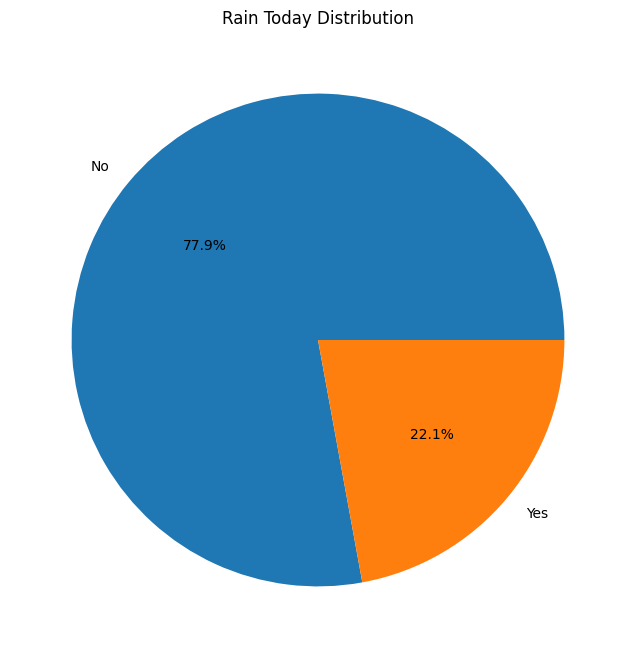

In [26]:
plt.figure(figsize=(8, 8))

df['RainToday'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('Rain Today Distribution')
plt.ylabel('')

plt.show()

Why did you choose this visualization?

I chose the pie chart to show the proportion of rainy and non-rainy days today.

What does this graph help you understand?

It gives a clear view of the class proportions in the RainToday variable.

Insight:

Most days are classified as non-rainy, while rainy days represent a smaller proportion of the observations.

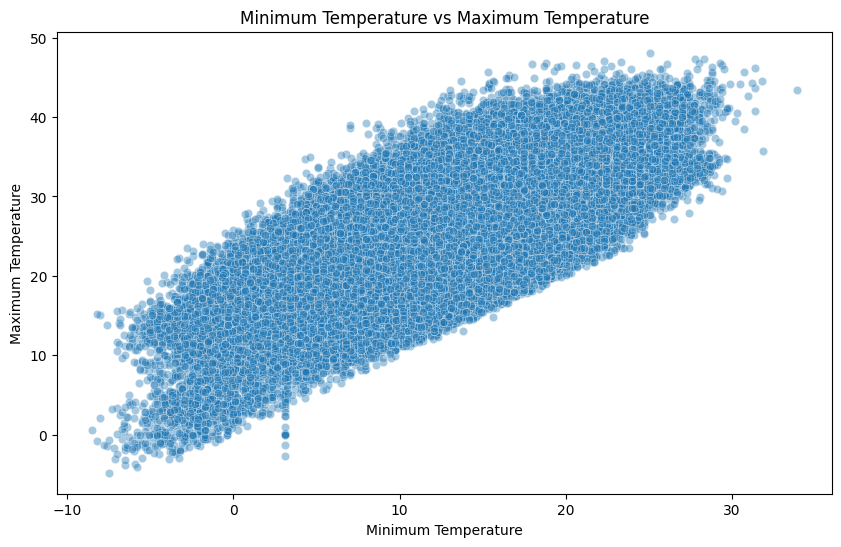

In [27]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='MinTemp',
    y='MaxTemp',
    alpha=.4
)

plt.title('Minimum Temperature vs Maximum Temperature')
plt.xlabel('Minimum Temperature')
plt.ylabel('Maximum Temperature')

plt.show()

Why did you choose this visualization?

I chose the scatter plot to examine the relationship between minimum and maximum temperature.

What does this graph help you understand?

It shows whether higher minimum temperatures are associated with higher maximum temperatures.

Insight:

There is a strong positive relationship between minimum and maximum temperature. As minimum temperature increases, maximum temperature generally increases as well.

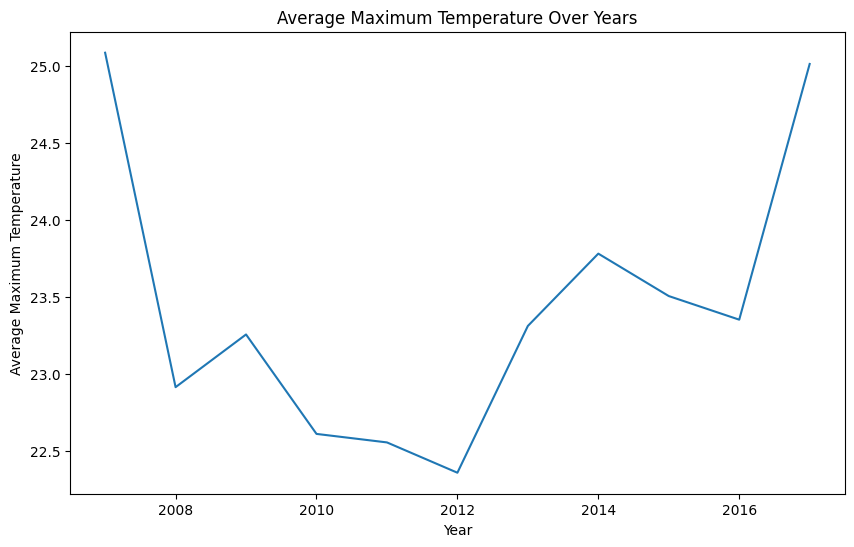

In [28]:
yearly_temp = df.groupby('Year')['MaxTemp'].mean().reset_index()

plt.figure(figsize=(10, 6))

sns.lineplot(
    data=yearly_temp,
    x='Year',
    y='MaxTemp'
)

plt.title('Average Maximum Temperature Over Years')
plt.xlabel('Year')
plt.ylabel('Average Maximum Temperature')

plt.show()

Why did you choose this visualization?

I chose the line chart to observe changes in average maximum temperature over the years.

What does this graph help you understand?

It helps identify general trends and variations in temperature over time.

Insight:

The average maximum temperature changes from year to year. The graph shows fluctuations rather than a consistent increasing or decreasing trend.

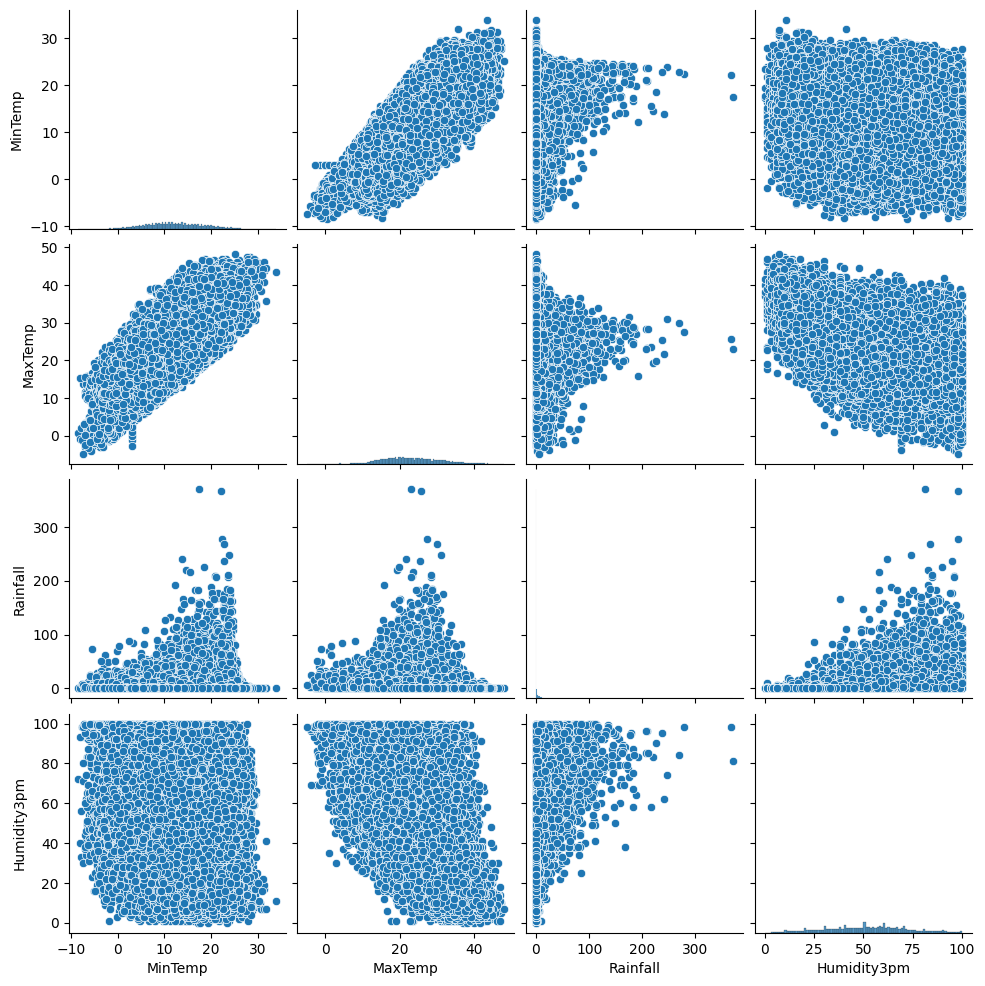

In [29]:
sns.pairplot(df[['MinTemp', 'MaxTemp', 'Rainfall', 'Humidity3pm']])
plt.show()

Why did you choose this visualization?

I chose the pairplot to examine relationships between several numerical weather variables at the same time.

What does this graph help you understand?

It helps identify correlations, patterns, and possible relationships between numerical variables.

Insight:

The pairplot shows strong relationships between some temperature variables, while other variables have weaker relationships. It also highlights the different distributions of the variables.

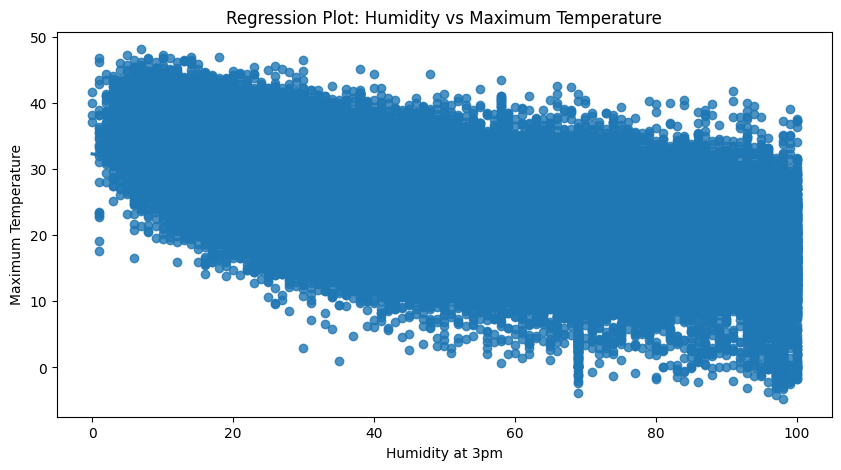

In [30]:
plt.figure(figsize=(10, 5))

sns.regplot(data=df, x='Humidity3pm', y='MaxTemp')

plt.title('Regression Plot: Humidity vs Maximum Temperature')
plt.xlabel('Humidity at 3pm')
plt.ylabel('Maximum Temperature')

plt.show()

Why did you choose this visualization?

I chose the regression plot to examine the relationship between humidity and maximum temperature.

What does this graph help you understand?

It shows the direction and strength of the relationship between humidity and maximum temperature.

Insight:

The plot shows a negative relationship between humidity and maximum temperature. As humidity increases, maximum temperature generally tends to decrease.

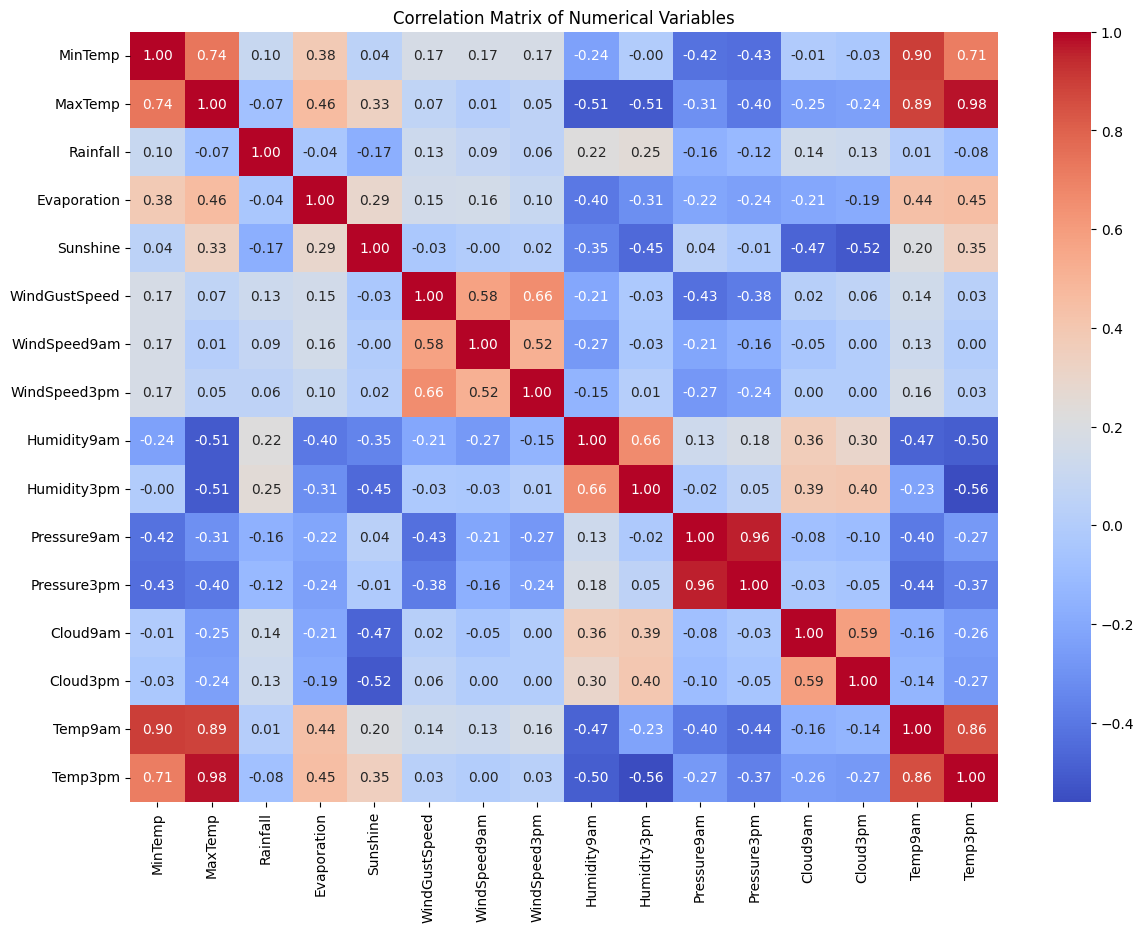

In [31]:
plt.figure(figsize=(14, 10))

correlation = df[numeric_col].corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix of Numerical Variables')
plt.show()

Why did you choose this visualization?

I chose the correlation heatmap to measure the relationships between numerical variables.

What does this graph help you understand?

It helps identify strongly correlated variables and possible relationships that may be useful for analysis and modeling.

Insight:

Temperature variables show strong positive correlations with each other, while humidity variables show negative relationships with temperature variables. This indicates that some weather variables are closely related.

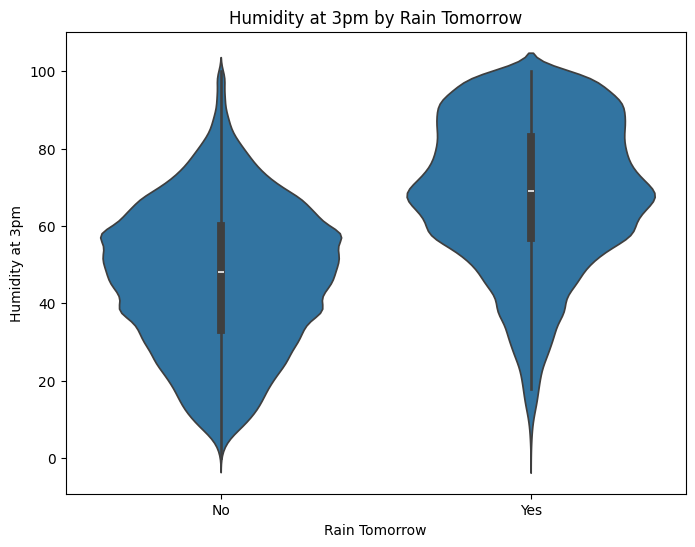

In [32]:
plt.figure(figsize=(8, 6))

sns.violinplot(
    data=df,
    x='RainTomorrow',
    y='Humidity3pm'
)

plt.title('Humidity at 3pm by Rain Tomorrow')
plt.xlabel('Rain Tomorrow')
plt.ylabel('Humidity at 3pm')

plt.show()

Why did you choose this visualization?

I chose the violin plot to compare the distribution of humidity at 3pm between rainy and non-rainy days.

What does this graph help you understand?

It shows the distribution, spread, and typical humidity levels for each RainTomorrow class.

Insight:

Days followed by rain generally have higher humidity at 3pm compared with days without rain. This suggests that afternoon humidity may be an important feature for predicting rainfall tomorrow.


We converted the Date column to datetime and extracted Year, Month, and Day to use them as useful features.

We removed RISK_MM because it is related to rainfall on the following day, which may cause data leakage when predicting RainTomorrow.

In [33]:
df

,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,...,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,Year,Month,Day
0,Albury,13.4,22.9,0.6,4.4,8.4,W,44.0,W,WNW,...,1007.1,8.0,7.0,16.9,21.8,No,No,2008,12,1
1,Albury,7.4,25.1,0.0,4.4,8.4,WNW,44.0,NNW,WSW,...,1007.8,8.0,7.0,17.2,24.3,No,No,2008,12,2
2,Albury,12.9,25.7,0.0,4.4,8.4,WSW,46.0,W,WSW,...,1008.7,8.0,2.0,21.0,23.2,No,No,2008,12,3
3,Albury,9.2,28.0,0.0,4.4,8.4,NE,24.0,SE,E,...,1012.8,8.0,7.0,18.1,26.5,No,No,2008,12,4
4,Albury,17.5,32.3,1.0,4.4,8.4,W,41.0,ENE,NW,...,1006.0,7.0,8.0,17.8,29.7,No,No,2008,12,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142188,Uluru,3.5,21.8,0.0,4.4,8.4,E,31.0,ESE,E,...,1021.2,7.0,5.0,9.4,20.9,No,No,2017,6,20
142189,Uluru,2.8,23.4,0.0,4.4,8.4,E,31.0,SE,ENE,...,1020.3,7.0,5.0,10.1,22.4,No,No,2017,6,21
142190,Uluru,3.6,25.3,0.0,4.4,8.4,NNW,22.0,SE,N,...,1019.1,7.0,5.0,10.9,24.5,No,No,2017,6,22
142191,Uluru,5.4,26.9,0.0,4.4,8.4,N,37.0,SE,WNW,...,1016.8,7.0,5.0,12.5,26.1,No,No,2017,6,23


5. Feature Engineering & Scaling

In [34]:
df["RainTomorrow"]=df["RainTomorrow"].map({
    "No": 0,
    "Yes": 1
})

X = df.drop(["RainTomorrow"], axis=1)
y = df["RainTomorrow"]

In [35]:
categorical_cols = X.select_dtypes(include='object').columns

print(categorical_cols)

Index(['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday'], dtype='str')


C:\Users\O.R.G\AppData\Local\Temp\ipykernel_8616\3643701492.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include='object').columns


## ⚙️ 5. Feature Engineering, Encoding & Data Scaling
* **One-Hot Encoding**: Converting categorical features into numerical format while avoiding multicollinearity using `drop_first=True`.
* **Train-Test Split**: Splitting the dataset with stratification (`stratify=y`) to maintain class balance.
* **Feature Scaling**: Normalizing features using `StandardScaler` fitted only on the training data to prevent data leakage.

In [36]:
X = pd.get_dummies(
    X,
    columns=categorical_cols,
    drop_first=True
)

In [37]:
df

,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,...,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,Year,Month,Day
0,Albury,13.4,22.9,0.6,4.4,8.4,W,44.0,W,WNW,...,1007.1,8.0,7.0,16.9,21.8,No,0,2008,12,1
1,Albury,7.4,25.1,0.0,4.4,8.4,WNW,44.0,NNW,WSW,...,1007.8,8.0,7.0,17.2,24.3,No,0,2008,12,2
2,Albury,12.9,25.7,0.0,4.4,8.4,WSW,46.0,W,WSW,...,1008.7,8.0,2.0,21.0,23.2,No,0,2008,12,3
3,Albury,9.2,28.0,0.0,4.4,8.4,NE,24.0,SE,E,...,1012.8,8.0,7.0,18.1,26.5,No,0,2008,12,4
4,Albury,17.5,32.3,1.0,4.4,8.4,W,41.0,ENE,NW,...,1006.0,7.0,8.0,17.8,29.7,No,0,2008,12,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142188,Uluru,3.5,21.8,0.0,4.4,8.4,E,31.0,ESE,E,...,1021.2,7.0,5.0,9.4,20.9,No,0,2017,6,20
142189,Uluru,2.8,23.4,0.0,4.4,8.4,E,31.0,SE,ENE,...,1020.3,7.0,5.0,10.1,22.4,No,0,2017,6,21
142190,Uluru,3.6,25.3,0.0,4.4,8.4,NNW,22.0,SE,N,...,1019.1,7.0,5.0,10.9,24.5,No,0,2017,6,22
142191,Uluru,5.4,26.9,0.0,4.4,8.4,N,37.0,SE,WNW,...,1016.8,7.0,5.0,12.5,26.1,No,0,2017,6,23


In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(113754, 113)
(28439, 113)


In [39]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

6. Model Training & Evaluation

In [40]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

model = LogisticRegression(max_iter=1000)

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print("Logistic Regression")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Logistic Regression
Accuracy : 0.8499243995921094
Precision: 0.7367947853450214
Recall   : 0.5141960784313725
F1 Score : 0.6056910569105691


In [41]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

print("KNN")
print("Accuracy :", accuracy_score(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn))
print("Recall   :", recall_score(y_test, y_pred_knn))
print("F1 Score :", f1_score(y_test, y_pred_knn))

KNN
Accuracy : 0.8068145856042758
Precision: 0.625106503834138
Recall   : 0.3452549019607843
F1 Score : 0.4448261924009701


In [47]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest")
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))

Random Forest
Accuracy : 0.8571328105770245
Precision: 0.7837506136475209
Recall   : 0.5008627450980392
F1 Score : 0.6111589625801512


## 🤖 6. Model Training & Evaluation
In this section, we train and evaluate multiple machine learning classifiers to predict rainfall. We utilize various metrics including Accuracy, Precision, Recall, and F1-Score to rigorously assess performance:

1. **Logistic Regression**: A linear model acting as our baseline.
2. **K-Nearest Neighbors (KNN)**: A distance-based classifier leveraging scaled features.
3. **Random Forest Classifier**: A powerful ensemble method capable of capturing non-linear patterns.

### --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

## Final Conclusion

This project analyzed the Australia Weather dataset and followed a complete machine learning workflow, including data understanding, data cleaning, exploratory data analysis, feature engineering, preprocessing, and model building.

The EDA revealed several important patterns in the weather data, including strong relationships between temperature-related variables and differences in weather conditions across locations. The target variable `RainTomorrow` was also found to be imbalanced, with non-rainy days representing the majority of observations.

Categorical variables were encoded using One-Hot Encoding, while numerical features were standardized before training the Logistic Regression model. The `RISK_MM` feature was removed because it could introduce data leakage when predicting whether it would rain the following day.

The Logistic Regression model achieved an accuracy of approximately 85%. However, the recall for the `Yes` class was approximately 51%, indicating that the model still misses a considerable number of rainy days.

Future improvements could include handling class imbalance, testing different classification algorithms, and applying feature selection or hyperparameter tuning to improve the model's ability to detect rainy days.